# XMV-Net — Skeleton

**Owner:** Rafid · **Scope:** the model the project is about (`§3`, `§6`, `§9` of the report)

This notebook is the full XMV-Net pipeline: data → frozen folds → model → composite loss → 5-fold training with
annealed schedules → post-training diagnosis → 5-fold ensemble inference → `test_submission.csv`. Every step has a
markdown cell above it saying **what to do** and **what to look for**.

| Component | State | Where |
|---|---|---|
| Two-pass CSV loader + memmap cache | ✅ | `data_loader.py`, Step 0 |
| Frozen 5-fold split with ID-hash tripwire | ✅ | `folds/`, Step 1 |
| View splitter · sparse feature gates · per-view encoders | ✅ | Step 2 |
| Gated attention fusion (Ilse `tanh ⊙ σ`) with annealed temperature | ✅ | Step 2 |
| Composite loss: BCE + aux BCE + attention entropy + gate L1 | ✅ | Step 3 |
| Pre-training diagnostics probe | ✅ | Step 4 |
| Training loop: AMP · early stopping on val AUC · linear schedules · checkpoints | ✅ | Step 5 |
| Post-training diagnosis: curves · attention · gates · cross-fold stability | ✅ | Step 6 |
| 5-fold ensemble inference → `test_submission.csv` | ✅ | Step 7 |
| Ablations A1 / A4 / A5 / A6 | 🔨 flags exist, runs not done | Step 5 `CONFIG` |

> **Every ablation is a `CONFIG` edit on this one notebook, never a forked copy.** A1 = `use_attention: False`.
> A4 = sweep `lam_aux` (0 is the collapse demo). A5 = `lam_ent`/`lam_gate` ends set to 0. A6 = swap the BCE call in `xmv_loss`.

> **Training-harness note.** The team plan was to share Siam's `train_utils.py`. It did not exist when Step 5 was
> written, so the loop here is self-contained. When it lands, reconcile — do not run two divergent loops for the
> same reported numbers.

---

## What the data actually looks like

| | |
|---|---|
| Train | 595,000 accounts · 12.68% churn · behaviour Jan–Mar, label = churn in Apr |
| Test | 255,000 accounts · **no label** — scored online; all local metrics come from CV on train |
| Split type | Account-level random (train IDs 1,3,5… / test IDs 2,4,6…), **not** temporal |
| Raw features | 88 numeric + `GENDER`, `REGION` |
| After preprocessing | **127 features across 8 views** (see below) |

**Three data facts that shape the model:**

1. **8 columns are constant zero** in both train and test (`salary_amt_7d/14d`, `salary_amt_ratio_7d/14d`,
   `salary_day_ratio_7d/14d`, `n_salary_7d/14d`). All 8 sit in the *monetary* view. They are dropped —
   a constant column's gate weight is unidentifiable and would inflate the sparsity metrics in `§5`.
2. **44 columns have structural NaNs** (up to 18.9%). They mean *"no transactions in that window"*, not
   *"unknown"* — so they are filled with `0` and paired with a `__isna` indicator assigned to the same view.
3. **The recency cluster is near-definitional.** `rec_ge30 == 1` → **94.2% churn** vs 5.4% otherwise;
   `recency_days` correlates r=0.79 with the label. Every model here will look great for the wrong reason.
   Sameen's **ablation A7** (drop the recency view) is the honest headline — treat pre-A7 numbers as provisional.

**Deviation from the proposal to flag at the next sync:** the proposal specifies **7** views. `GENDER` and
`REGION` belong to none of them, so they form an 8th **demographic** view. Update `§3` of the report to say 8.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

import data_loader as dl

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAMPLE_ROWS = None   # None = full 595k. Keep small while iterating on CPU.

print(f"torch {torch.__version__} | device {DEVICE}")

torch 2.4.0+cpu | device cpu


---
## Step 0 — Data

All CSV handling lives in [`data_loader.py`](data_loader.py) (documented in [`docs/data_loader.md`](docs/data_loader.md)).

The first call runs a two-pass build: pass 1 discovers the schema from train (row count, NaN columns,
constant columns, clip quantiles, skew), pass 2 streams both CSVs into memmapped `.npy` caches.
Roughly 11 s once; every later call is a ~0.02 s memmap open.

In [2]:
dl.build_cache()

train = dl.load_train(n_rows=SAMPLE_ROWS)
test = dl.load_test()

FEATURE_COLS = train.feature_cols
VIEW_GROUPS = train.view_groups

assert train.feature_cols == test.feature_cols, "FEATURE_COLS drift between train and test"
print(f"train {train.X.shape}  churn={train.y.mean():.4f}   test {test.X.shape}")
print(train.summary().to_string(index=False))

cache hit: D:\ACADEMY FOLDER\IUT Academics\Semester 8 (4.2)\CSE 4840 Pattern Recognition\Interpretable-Churn-Predictor\Dataset\_cache
train (595000, 127)  churn=0.1268   test (255000, 127)
       view  n_features
    recency          11
  frequency          50
   monetary          13
    network           4
   calendar          21
    balance          11
dec_segment           6
demographic          11


### ⚠️ Read the view sizes before building the model

The views are badly unbalanced: **frequency has 50 features, network has 4.** Three consequences:

- Every view is squeezed to the same 32-d embedding, so attention compares a 50-input encoder and a 4-input
  encoder on equal footing. Expect frequency to dominate attention early.
- Encoder capacity per input differs 12×: the network encoder (4→64→32) can memorise; the frequency encoder
  (50→64→32) must compress. Identical dropout and weight decay are therefore *not* identical regularisation.
- **The gate L1 penalty is not view-neutral — but not for the obvious reason.** The per-gate penalty gradient
  `(λ_gate/τ)·σ'(w/τ)` is identical everywhere regardless of width. The asymmetry is on the *benefit* side: a gate
  stays open only while its marginal BCE gradient beats that constant pressure, and in a view full of redundant
  features (`n_trx_7d/14d/30d/60d/90d` are nested windows of the same count) each feature's marginal value is
  small. So wide-**and-redundant** views sparsify hardest at equal λ. `gate_reduction="mean"` equalises each
  view's total penalty budget instead — at the cost of per-gate pressure ∝ 1/d_v, which over-sparsifies *narrow*
  views. Neither is neutral; read ablation A5 with this in mind.

Options to raise at the sync: merge `network` into `frequency` (7 views), or keep 8 and report the imbalance honestly.

In [3]:
# Sanity: views are disjoint and cover every feature exactly once.
_all = np.concatenate(list(VIEW_GROUPS.values()))
assert len(_all) == len(np.unique(_all)) == len(FEATURE_COLS)

# The leak you will be asked about in the viva.
i = FEATURE_COLS.index("rec_ge30")
flag = np.asarray(train.X[:, i]) > 0
print(f"rec_ge30=1 -> churn {train.y[flag].mean():.3f}  (n={flag.sum():,})")
print(f"rec_ge30=0 -> churn {train.y[~flag].mean():.3f}  (n={(~flag).sum():,})")

rec_ge30=1 -> churn 0.944  (n=49,267)
rec_ge30=0 -> churn 0.053  (n=545,733)


---
## Step 1 — Folds and standardisation

### The frozen split ✅

`folds/frozen_folds_5.npy` is the **shared 5-fold split**, generated once over all 595,000 train rows and
committed to the repo. Every model in the project — XMV-Net, the GBDTs, the neural baselines, NAM — must use
this exact file, or the numbers are not comparable and the benchmark table in `§7` means nothing.

| | |
|---|---|
| Splitter | `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` on `CHURN` |
| Rows | 595,000 → **119,000 per fold**, exactly |
| Churn per fold | **0.126782** in all five (overall: 0.126782) |
| Manifest | `folds/frozen_folds_5.json` — seed, fold sizes, per-fold churn, `ids_sha256` |

**Why plain `StratifiedKFold` is right here** — verified, not assumed:

- `ACCOUNT_ID` is **unique**: 595,000 rows, 595,000 distinct IDs. No customer spans two folds, so `GroupKFold`
  would group nothing.
- Train and test share **zero** IDs.
- The temporal structure is already fixed by construction (Jan–Mar behaviour → April label), so a time-series
  split has nothing left to protect against. Every row has the same observation window.

### The drift tripwire

A fold file is just an array of integers — it has no idea which rows it belongs to. If row order ever changes,
folds silently mis-align and you get confident, wrong, *entirely plausible-looking* numbers with no error
anywhere. Same failure class as the `FEATURE_COLS` column-order bug the team was warned about.

So the manifest stores a SHA-256 of the `ACCOUNT_ID` array the split was built on, and `make_folds(..., ids=...)`
verifies it. **Always pass `ids=`** — it costs nothing and it is the only thing standing between you and that bug.

`make_folds` now **raises** if the frozen file is missing, rather than quietly inventing a placeholder split.
Placeholder folds are still reachable via `allow_placeholder=True`, for throwaway experiments only.

> ⚠️ **Regenerating the split silently invalidates every number already reported.** `freeze_folds()` refuses to
> overwrite without `force=True`. Per the team briefs the frozen split is Sameen's deliverable — flag at the next
> sync that this file now exists, so the team ends up with one canonical split rather than two.

> ℹ️ With `SAMPLE_ROWS` set, `make_folds` returns a **prefix** of the frozen assignment, so sample-mode fold
> sizes below will not be 119,000. That is expected; only full-data runs produce reportable numbers.

### Standardisation is fitted per fold, on training rows only

Fitting the scaler on all rows leaks the validation distribution into training. Mild in effect, free to avoid —
and this project is partly *about* leakage discipline, so it would be a bad look in the report.

In [4]:
# Run ONCE per clone, then commit folds/. No-op if the file already exists.
dl.freeze_folds()

folds = dl.make_folds(train.y, ids=train.ids)   # ids= enables the drift tripwire

print(pd.DataFrame({
    "fold": range(dl.N_SPLITS),
    "n_val": [int((folds == k).sum()) for k in range(dl.N_SPLITS)],
    "churn": [round(float(train.y[folds == k].mean()), 6) for k in range(dl.N_SPLITS)],
}).to_string(index=False))

frozen folds already exist: D:\ACADEMY FOLDER\IUT Academics\Semester 8 (4.2)\CSE 4840 Pattern Recognition\Interpretable-Churn-Predictor\folds\frozen_folds_5.npy  (pass force=True to regenerate)
FROZEN folds: frozen_folds_5.npy | seed 42 | all 595,000 rows | ids verified
 fold  n_val    churn
    0 119000 0.126782
    1 119000 0.126782
    2 119000 0.126782
    3 119000 0.126782
    4 119000 0.126782


In [5]:
def get_fold(fold: int):
    """Standardised (Xtr, ytr, Xva, yva, mean, std) for one fold. Scaler is fitted on TRAIN rows only.

    The scaler is returned because inference must standardise the test set with the *same* mean/std
    each fold model was trained against -- it is saved into that fold's checkpoint.
    """
    tr_idx = np.where(folds != fold)[0]
    va_idx = np.where(folds == fold)[0]
    mean, std = dl.fit_standardizer(train.X, tr_idx)
    return (
        dl.apply_standardizer(np.asarray(train.X[tr_idx]), mean, std),
        train.y[tr_idx].astype(np.float32),
        dl.apply_standardizer(np.asarray(train.X[va_idx]), mean, std),
        train.y[va_idx].astype(np.float32),
        mean, std,
    )


FOLD = 0
Xtr, ytr, Xva, yva, mean, std = get_fold(FOLD)
print(f"fold {FOLD}: train {Xtr.shape} churn={ytr.mean():.4f} | val {Xva.shape} churn={yva.mean():.4f}")

fold 0: train (476000, 127) churn=0.1268 | val (119000, 127) churn=0.1268


---
## Step 2 — Architecture

```
        x  (B, 127)
         │
         ├── split by view ──►  x⁽ᵛ⁾  for v = 1..8
         │                       │
         │                  ┌────┴─────┐
         │                  │ gate m⁽ᵛ⁾│   m⁽ᵛ⁾ = σ(w⁽ᵛ⁾ / τ)      ← feature-level explanation
         │                  └────┬─────┘
         │                       │  x⁽ᵛ⁾ ⊙ m⁽ᵛ⁾
         │                  ┌────┴─────┐
         │                  │ encoder  │   Linear→BN→GELU→Drop ×2  (·→64→32)
         │                  └────┬─────┘
         │                       │  h⁽ᵛ⁾ (B, 32)
         │              ┌────────┼────────┐
         │              │                 │
         │        ┌─────┴─────┐    ┌──────┴──────┐
         │        │ aux head  │    │  attention  │   aᵥ ∝ exp(wᵀ(tanh(Vh⁽ᵛ⁾) ⊙ σ(Uh⁽ᵛ⁾)))
         │        └─────┬─────┘    └──────┬──────┘   ← view-level explanation
         │              │                 │  z = Σᵥ aᵥ h⁽ᵛ⁾
         │       aux logits (8)     ┌─────┴─────┐
         │                          │   head    │
         │                          └─────┬─────┘
         │                             logit
```

### Two design points worth understanding now

**Why `tanh ⊙ σ` gating instead of plain dot-product attention?** With only 8 items, plain
`softmax(wᵀh)` saturates — one view takes ~all the mass within a few epochs and never recovers. The Ilse
*et al.* gated form gives the scoring function a multiplicative bypass (`σ(Uh)`), which keeps gradients
alive for low-scoring views.

**Why the auxiliary heads are not optional.** Gradient reaching encoder *v* through the fused path is
scaled by `aᵥ`. A view that starts with low attention gets a small gradient → learns slowly → stays
uninformative → keeps low attention. That is a self-reinforcing collapse. The aux heads give every encoder
an **unconditional** gradient path, independent of `aᵥ`. Ablation **A4** (`λ_aux = 0`) is the row that
demonstrates this — expect it to look visibly worse, and that is the point.

In [6]:
class FeatureGate(nn.Module):
    """Learned soft feature mask m = sigmoid(w / tau), applied elementwise."""

    def __init__(self, n_features: int, tau: float = 1.0, init: float = 1.0):
        super().__init__()
        self.w = nn.Parameter(torch.full((n_features,), init))
        self.register_buffer("tau", torch.tensor(float(tau)))

    def mask(self) -> torch.Tensor:
        return torch.sigmoid(self.w / self.tau)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.mask()


class ViewEncoder(nn.Module):
    """Gate -> 2-layer MLP -> embedding of size `out_dim`."""

    def __init__(self, in_dim: int, hidden: int = 64, out_dim: int = 32,
                 dropout: float = 0.1, tau: float = 1.0):
        super().__init__()
        self.gate = FeatureGate(in_dim, tau=tau)
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim), nn.BatchNorm1d(out_dim), nn.GELU(), nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(self.gate(x))

### Gated attention fusion ✅

$$e_v = \mathbf{w}^\top\big(\tanh(V h^{(v)}) \odot \sigma(U h^{(v)})\big), \qquad a_v = \mathrm{softmax}_v(e_v / T)$$

$V, U \in \mathbb{R}^{A\times d}$, $\mathbf{w}\in\mathbb{R}^{A}$ with $d=32$, $A=16$. Input `H` is `(B, 8, 32)`;
output is the fused `z` `(B, 32)` and the attention `a` `(B, 8)`, rows summing to 1.

**Temperature $T$ is a registered buffer, not a Python float.** Two reasons:

- `model.set_temp(value)` overwrites it in place each epoch — that is how the annealing schedule reaches the module.
- Buffers live in `state_dict`, so a checkpoint restores the *exact* $T$ (and gate $\tau$) that was live at the
  best epoch. Inference then sees the same sharpness the validation AUC was measured at. As a plain attribute,
  reloading would silently reset it to the constructor default.

`mean_fusion=True` skips the scorer and returns uniform $a_v = 1/8$ — **ablation A1**, reachable as
`XMVNet(..., use_attention=False)` / `CONFIG["use_attention"] = False`.

In [7]:
class GatedAttention(nn.Module):
    """Ilse-style gated attention over view embeddings. mean_fusion=True -> uniform weights (ablation A1)."""

    def __init__(self, emb_dim: int = 32, attn_dim: int = 16, temp: float = 2.0, mean_fusion: bool = False):
        super().__init__()
        self.V = nn.Linear(emb_dim, attn_dim, bias=False)  # bias=False makes it a matrix applied to the last dim
        self.U = nn.Linear(emb_dim, attn_dim, bias=False)  # so (B, 8, 32) -> (B, 8, 16)
        self.W = nn.Linear(attn_dim, 1, bias=False)
        self.mean_fusion = mean_fusion
        # temp is annealed 2.0 -> 0.5 by the training loop via set_temp():
        # distributed attention at the start, sharper attention at the end of training
        self.register_buffer("temp", torch.tensor(float(temp)))

    def forward(self, H: torch.Tensor):
        B, V, _ = H.shape
        if self.mean_fusion:
            a = H.new_full((B, V), 1.0 / V)
        else:
            scores = self.W(torch.tanh(self.V(H)) * torch.sigmoid(self.U(H))).squeeze(-1)
            a = torch.softmax(scores / self.temp, dim=1)
        z = (a.unsqueeze(-1) * H).sum(dim=1)
        return z, a

In [8]:
class XMVNet(nn.Module):
    """Multi-view encoder -> gated attention fusion -> prediction head, plus per-view aux heads."""

    def __init__(self, view_groups: dict[str, np.ndarray], hidden: int = 64, emb_dim: int = 32,
                 attn_dim: int = 16, dropout: float = 0.1, tau: float = 1.0, temp: float = 2.0,
                 use_attention: bool = True):
        super().__init__()
        self.view_names = list(view_groups.keys())
        self.use_attention = use_attention

        for name, idx in view_groups.items():
            self.register_buffer(f"idx_{name}", torch.as_tensor(np.asarray(idx), dtype=torch.long))

        self.encoders = nn.ModuleDict({
            name: ViewEncoder(len(idx), hidden, emb_dim, dropout, tau)
            for name, idx in view_groups.items()
        })
        self.aux_heads = nn.ModuleDict({name: nn.Linear(emb_dim, 1) for name in view_groups})
        self.fusion = GatedAttention(emb_dim, attn_dim, temp, mean_fusion=not use_attention)
        self.head = nn.Sequential(nn.Linear(emb_dim, 32), nn.GELU(), nn.Linear(32, 1))

    def forward(self, x: torch.Tensor) -> dict:
        embeddings, aux_logits = [], []
        for name in self.view_names:
            h = self.encoders[name](x[:, getattr(self, f"idx_{name}")])
            embeddings.append(h)
            aux_logits.append(self.aux_heads[name](h).squeeze(-1))

        H = torch.stack(embeddings, dim=1)
        z, a = self.fusion(H)

        return {
            "logit": self.head(z).squeeze(-1),
            "attn": a,
            "aux_logits": torch.stack(aux_logits, dim=1),
            "gates": {n: self.encoders[n].gate.mask() for n in self.view_names},
        }

    @torch.no_grad()
    def set_tau(self, value: float) -> None:
        for name in self.view_names:
            self.encoders[name].gate.tau.fill_(value)

    @torch.no_grad()
    def set_temp(self, value: float) -> None:
        self.fusion.temp.fill_(value)

### Annealing — one linear ramp, and what it is allowed to touch

`anneal(epoch, total, start, end)` is plain linear interpolation: `start` at epoch 0, `end` at epoch `total-1`,
clamped after that. Step 5 applies it every epoch. A `(start, end)` pair with `start == end` is how a constant
is written, so everything lives in one dict.

| Parameter | Start → End | What the ramp does | Evidence |
|---|---|---|---|
| attention temperature $T$ | 2.0 → 0.5 | softmax goes from near-uniform to decisive | a monotone transform of the scores: it sharpens without changing which view wins, so it is a safe dial. Ablating it (T fixed at 2.0) changed final $H(a)$ by only 0.05 nats |
| entropy weight $\lambda_{ent}$ | 0 → 0.05 | warms in the **two-sided** $(H-H^*)^2$ penalty | with a *linear* $\lambda_{ent}H$ penalty, $\lambda=0.002$ was already enough to crush $H(a)$ from 1.85 to 0.36 by epoch 3 |
| gate temperature $\tau$ | **1.0 → 1.0 (fixed)** | nothing — deliberately | annealing it 1.0 → 0.5 left val AUC identical (0.985424 both) but pushed *24%* of gates below the 0.1 "closed" threshold purely by sharpening $\sigma(w/\tau)$. That is a measurement artifact, not learned sparsity |
| gate weight $\lambda_{gate}$ | 0.002 → 0.002 | constant | at 0.01 every gate shrank uniformly (0.65 → 0.30) while BCE stayed flat — global shrinkage, not feature selection |

`total` is the **planned** budget `CONFIG["epochs"]`. With `patience=None` the budget is always fully traversed,
so all five fold models finish at exactly the same $T$ and $\lambda_{ent}$ — which is what makes their
explanations comparable to each other.

In [9]:
## standalone value annealer
def anneal(epoch: int, total: int, start: float, end: float) -> float:
    if total <= 1:
        return end
    return start + (end - start) * min(epoch / (total - 1), 1.0)

In [10]:
model = XMVNet(VIEW_GROUPS).to(DEVICE)

xb = torch.from_numpy(Xtr[:8]).to(DEVICE)
out = model(xb)

print(f"params: {sum(p.numel() for p in model.parameters()):,}")
print(f"logit      {tuple(out['logit'].shape)}")
print(f"attn       {tuple(out['attn'].shape)}  rowsum={out['attn'].sum(1)[0].item():.4f}")
print(f"aux_logits {tuple(out['aux_logits'].shape)}")
for n, g in out["gates"].items():
    print(f"  gate[{n:<12}] dim={tuple(g.shape)} mean={g.mean().item():.3f}")

params: 29,336
logit      (8,)
attn       (8, 8)  rowsum=1.0000
aux_logits (8, 8)
  gate[recency     ] dim=(11,) mean=0.731
  gate[frequency   ] dim=(50,) mean=0.731
  gate[monetary    ] dim=(13,) mean=0.731
  gate[network     ] dim=(4,) mean=0.731
  gate[calendar    ] dim=(21,) mean=0.731
  gate[balance     ] dim=(11,) mean=0.731
  gate[dec_segment ] dim=(6,) mean=0.731
  gate[demographic ] dim=(11,) mean=0.731


---
## Step 3 — Loss ✅

$$\mathcal{L} = \underbrace{\mathcal{L}_{BCE}(\text{fused})}_{\text{primary}} + \lambda_{aux}\sum_v \mathcal{L}_{BCE}(\text{head}_v) + \lambda_{ent}\big(H(a) - H^*\big)^2 + \lambda_{gate}\sum_v \lVert m^{(v)} \rVert_1$$

All four terms are in `xmv_loss` below. It returns the total **and** each unweighted term, plus `ent_pen`, so the
log can show which one is moving.

| Term | λ | What it buys | Failure mode if wrong |
|---|---|---|---|
| primary BCE | — | calibrated probabilities (needed for `§8` ECE/Brier) | — |
| aux BCE | 0.3 | unconditional gradient to every encoder | λ too high → fused head under-trains |
| attention entropy | **0 → 0.05 on $(H-H^*)^2$, $H^*=1.0$** | decisive but non-degenerate view attributions | `ent_mode="linear"` reproduces the documented collapse — see below |
| gate L1 | 0.002, `gate_reduction="mean"` | within-view sparsity | too high → *uniform* shrinkage of every gate, which is not selection; see the view-width note in Step 0 for `mean` vs `sum` |

### ⚠️ Why the entropy penalty is two-sided, not linear

The proposal specifies $+\lambda_{ent}H(a)$. Minimising that has **no stationary point**: the gradient keeps
pushing toward one-hot no matter how low $H$ already is, and it only stops if the BCE pushes back. On this
dataset the views are highly redundant, so the BCE barely cares which view is used — it provides almost no
counter-pressure. Measured on fold 0, full data:

| fold-0 config | $H(a)$ at epoch 5 | val AUC |
|---|---|---|
| $\lambda_{ent}$ 0 → 0.02, linear | **0.105** | 0.985210 |
| $\lambda_{ent} = 0$ (same $T$ ramp) | 1.674 | 0.985345 |
| $\lambda_{ent} = 0$, $T$ fixed at 2.0 | 1.726 | 0.985339 |

So the collapse was caused *entirely* by $\lambda_{ent}$, not the temperature ramp — and shrinking λ only delays
it. Replacing the term with $(H - H^*)^2$ gives it a stationary point at $H = H^*$: entropy now settles at
≈0.95–0.99 and **stays there** for the rest of training, at slightly better AUC.

**Two sign conventions that are still easy to get backwards:**
- $H(a) = -\sum_v a_v \log a_v$ is **maximal** for uniform attention. Under `ent_mode="linear"` the term enters
  with a **`+`** to minimise entropy; writing $-\lambda_{ent}H(a)$ pushes toward uniform — the opposite. Under
  `"target"` the sign is handled by the square, which is part of why it is safer.
- The gate L1 uses `mask()` (post-sigmoid, in [0,1]), **not** the raw logit `w`. Penalising `w` drives it to 0,
  which is `sigmoid(0) = 0.5` — a half-open gate, not a closed one.

In [11]:
def xmv_loss(out: dict, y: torch.Tensor, lam_aux: float = 0.3, lam_ent: float = 0.0,
             lam_gate: float = 0.0, gate_reduction: str = "mean",
             ent_mode: str = "target", H_target: float = 1.0) -> tuple[torch.Tensor, dict]:
    bce = F.binary_cross_entropy_with_logits(out["logit"], y)
    aux_logits = out["aux_logits"]
    # y.unsqueeze(1).expand_as(aux_logits) turns (B,) into (B, 1) then stretches to (B, 8)
    aux = F.binary_cross_entropy_with_logits(aux_logits, y.unsqueeze(1).expand_as(aux_logits))

    a = out["attn"].clamp_min(1e-8)
    H = -(a * a.log()).sum(dim=1).mean()
    if ent_mode == "target":
        # two-sided: penalises being MORE decisive than H_target as well as less, so it has
        # a stationary point at H = H_target. The linear form has none -- see the markdown above.
        ent = (H - H_target) ** 2
    elif ent_mode == "linear":
        ent = H
    else:
        raise ValueError(f"ent_mode must be 'target' or 'linear', got {ent_mode!r}")

    masks = out["gates"].values()
    if gate_reduction == "mean":
        gate = torch.stack([m.mean() for m in masks]).sum()
    elif gate_reduction == "sum":
        gate = torch.stack([m.sum() for m in masks]).sum()
    else:
        raise ValueError(f"gate_reduction must be 'mean' or 'sum', got {gate_reduction!r}")

    total = bce + lam_aux * aux + lam_ent * ent + lam_gate * gate
    # "ent" logs the raw entropy H(a) so the curve is readable across ent_mode settings;
    # "ent_pen" is what the optimiser actually sees before lam_ent.
    return total, {"bce": bce.item(), "aux": aux.item(), "ent": H.item(),
                   "ent_pen": ent.item(), "gate": gate.item()}

---
## Step 4 — Diagnostics (wire these before the first real training run)

Both documented failure modes are silent — training loss looks fine while the *explanation*, which is the
entire point of the project, quietly dies. Log these **every epoch** from run #1, not after something breaks.

| Diagnostic | Healthy | Alarm | Fix |
|---|---|---|---|
| mean attention entropy `H(a)` | rises toward `ln(8) ≈ 2.08` early, falls slowly | **< 0.3 nats before epoch 5** | λ_ent too high, or aux heads mis-wired |
| per-view mean gate `m⁽ᵛ⁾` | spread across (0,1) | **all ≈ 1.0** (saturated) | raise λ_gate an order of magnitude |
| per-view attention **variance** across customers | clearly > 0 | ≈ 0 (e.g. `0.34 ± 0.01`) | model has collapsed to fixed global weights — the "per-customer attention" claim would be false |

That third row is Tausif's sanity check from their brief, but it is much cheaper to catch here than in week 3.

In [12]:
@torch.no_grad()
def diagnostics(model: XMVNet, X: np.ndarray, n: int = 4096, batch: int = 1024) -> dict:
    """Quick standalone probe. The training loop in Step 5 logs the same quantities every epoch."""
    model.eval()
    attn = []
    for s in range(0, min(n, len(X)), batch):
        xb = torch.from_numpy(X[s:s + batch]).to(DEVICE)
        attn.append(model(xb)["attn"].cpu())
    A = torch.cat(attn)

    ent = -(A.clamp_min(1e-8) * A.clamp_min(1e-8).log()).sum(1).mean().item()
    gates = {n_: g.mean().item() for n_, g in model(torch.from_numpy(X[:2]).to(DEVICE))["gates"].items()}
    model.train()
    return {
        "attn_entropy": ent,
        "attn_entropy_max": float(np.log(A.shape[1])),
        "attn_mean": dict(zip(model.view_names, A.mean(0).tolist())),
        "attn_std": dict(zip(model.view_names, A.std(0).tolist())),
        "gate_mean": gates,
    }


d = diagnostics(model, Xtr)
print("UNTRAINED baseline (random init, T=2.0) -- compare against the post-training tables in Step 6:")
print(f"H(a) = {d['attn_entropy']:.3f} / {d['attn_entropy_max']:.3f} max")
print(pd.DataFrame({"attn_mean": d["attn_mean"], "attn_std": d["attn_std"],
                    "gate_mean": d["gate_mean"]}).round(4).to_string())

UNTRAINED baseline (random init, T=2.0) -- compare against the post-training tables in Step 6:
H(a) = 2.079 / 2.079 max
             attn_mean  attn_std  gate_mean
recency         0.1250    0.0008     0.7311
frequency       0.1241    0.0010     0.7311
monetary        0.1259    0.0009     0.7311
network         0.1243    0.0004     0.7311
calendar        0.1249    0.0007     0.7311
balance         0.1256    0.0006     0.7311
dec_segment     0.1250    0.0009     0.7311
demographic     0.1252    0.0006     0.7311


---
## Step 5 — Training

### What this does

One `train_one_fold()` call = one fold model. It trains on the four training folds and evaluates on the held-out
fold every epoch. With `patience=None` it runs the **full fixed budget and keeps the final epoch**; with an int it
early-stops on val AUC and keeps the peak. The peak epoch is recorded either way, so you can always see what
early stopping *would* have chosen.

| Piece | Choice | Why |
|---|---|---|
| Optimiser | AdamW, lr 1e-3, weight decay 1e-4 | boring and reliable for a ~28k-parameter net |
| Precision | AMP (fp16 autocast + `GradScaler`) **only on CUDA** | roughly halves T4 time; the loss is computed in fp32 *outside* autocast so the entropy/log terms cannot underflow |
| Batching | index-slicing a device-resident tensor | 465 batches/epoch on full data; `DataLoader`'s per-row collate is the bottleneck on tabular data, not the model |
| **Model selection** | **fixed 20-epoch budget, final epoch kept** | see below — early stopping on AUC was selecting noise |
| Schedules | `SCHEDULES` dict of `(start, end)`, applied every epoch via `anneal()` | see the annealing table in Step 2 |
| Seed | `SEED + fold` | each fold reproducible on its own |

### ⚠️ Why early stopping is off by default

Measured over the previous full run: within-fold val AUC **range** was 0.0002–0.0007, while epoch-to-epoch
**std** after epoch 1 was ~0.0001. Early stopping was therefore choosing between epochs that differ by less than
the noise. It picked epochs 4, 2, 7, 4, 5 — and $H(a)$ at those epochs was **0.197, 0.790, 0.062, 0.173, 0.161**.

That is a 13× spread in explanation sharpness across the five models that get averaged into one submission, and
whose attention Tausif's faithfulness benchmark treats as a single method. A fixed budget lands every fold on the
same $T$ and $\lambda_{ent}$, so the ensemble has one explanation regime instead of five. The accuracy cost is
inside the noise band.

### What gets saved per fold

- `checkpoints/xmvnet{tag}_fold{k}.pt` — weights **plus** that fold's scaler (`mean`, `std`), `FEATURE_COLS`,
  config, schedules, kept epoch and peak epoch. Inference refuses to run if `FEATURE_COLS` does not match.
- One history row per epoch: every loss term (incl. `ent_pen`), val AUC / AP / P@10 / R@10, attention entropy,
  mean attention std across customers, per-view gate mean, and the live `temp` / `tau` / `lam_ent`.

### Before you run

1. **`SAMPLE_ROWS` in the first cell.** `50_000` = CPU smoke run, ~3 min for 5 folds. `None` = the real thing —
   measured at **~12 s/epoch on CPU**, so ~20 min for the whole 5-fold run at the 20-epoch budget, faster on the
   T4. A sample run tags every
   output `_sampleN` and refuses to name the submission `test_submission.csv`.
2. Restart kernel → Run All. Never trust a re-run of one cell.

### What to watch in the per-epoch log

| Column | Healthy | Alarm |
|---|---|---|
| `val auc` | climbs, plateaus ~0.985 by epoch 2 (that is the recency leak, not genius) | flat at 0.5 → labels/features misaligned; falling from epoch 1 → lr too high |
| `H(a)` | falls from ≈2.08 and **parks at $H^*$ = 1.0 ± 0.05** from about epoch 2 | still drifting down at the last epoch → the target term is not binding, raise the `lam_ent` end |
| `attn_std` | settles ≈ 0.15 | ≈ 0.00 → attention identical for every customer → no per-customer explanation exists |
| `aux` vs `bce` | `aux` within ~2× of `bce` | `aux` ≫ `bce` → some view cannot predict alone (fine for `demographic`, suspicious for `frequency`) |
| `gate_mean` (Step 6) | drifts down **gently**, stays well clear of 0.1 | halving every epoch → λ_gate too high; it is shrinking all gates uniformly, not selecting |
| epoch time | 1–3 s on T4, ~12 s on CPU with full data | |

In [ ]:
import copy, json, time
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

CONFIG = dict(
    # patience=None -> FIXED epoch budget, no early stopping, final-epoch weights kept.
    # Early stopping on val AUC was selecting noise: within-fold AUC range is 2e-4..7e-4 while
    # epoch-to-epoch std is ~1e-4, so the five fold models ended at H(a) 0.06..0.79 -- a 13x
    # spread in explanation sharpness across the ensemble. A fixed budget lands every fold on
    # the same schedule point, so the members share one explanation regime.
    epochs=20, patience=None,
    batch_size=1024, lr=1e-3, weight_decay=1e-4,
    lam_aux=0.3, lam_gate=0.002, gate_reduction="mean",
    ent_mode="target", H_target=1.0,   # two-sided (H - H*)^2; "linear" reproduces the old collapse
    hidden=64, emb_dim=32, attn_dim=16, dropout=0.1,
    use_attention=True,                # False -> ablation A1 (uniform mean fusion)
    amp=(DEVICE.type == "cuda"),
)

SCHEDULES = dict(
    temp=(2.0, 0.5),                   # attention sharpness dial
    tau=(1.0, 1.0),                    # FIXED: annealing tau manufactures fake gate sparsity
    lam_ent=(0.0, 0.05),               # weight on (H - H_target)^2, warmed in from 0
    lam_gate=(0.002, 0.002),           # constant; 0.01 drove uniform shrinkage, not selection
)

RUN_TAG = "" if SAMPLE_ROWS is None else f"_sample{SAMPLE_ROWS}"
CKPT_DIR = Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
AMP_DTYPE = torch.float16 if DEVICE.type == "cuda" else torch.bfloat16


def schedule_at(epoch: int) -> dict:
    return {k: anneal(epoch, CONFIG["epochs"], s, e) for k, (s, e) in SCHEDULES.items()}


def metrics(y_true: np.ndarray, p: np.ndarray, top_frac: float = 0.10) -> dict:
    k = max(1, int(round(top_frac * len(p))))
    top = np.argsort(-p)[:k]
    tp = float(y_true[top].sum())
    return dict(auc=roc_auc_score(y_true, p), ap=average_precision_score(y_true, p),
                p_at_10=tp / k, r_at_10=tp / max(1.0, float(y_true.sum())))


def iterate_minibatches(X: torch.Tensor, y, batch_size: int, shuffle: bool, generator=None):
    n = X.shape[0]
    idx = torch.randperm(n, generator=generator).to(X.device) if shuffle else torch.arange(n, device=X.device)
    for s in range(0, n, batch_size):
        b = idx[s:s + batch_size]
        yield X[b], (None if y is None else y[b])


@torch.no_grad()
def predict(model: XMVNet, X: torch.Tensor, batch_size: int = 8192, want_attn: bool = False):
    model.eval()
    probs, attn = [], []
    for xb, _ in iterate_minibatches(X, None, batch_size, shuffle=False):
        out = model(xb)
        probs.append(torch.sigmoid(out["logit"].float()).cpu())
        if want_attn:
            attn.append(out["attn"].float().cpu())
    model.train()
    p = torch.cat(probs).numpy()
    return (p, torch.cat(attn).numpy()) if want_attn else p


print(f"RUN_TAG={RUN_TAG!r}  device={DEVICE}  amp={CONFIG['amp']}")
print("schedule at epoch 0 :", {k: round(v, 3) for k, v in schedule_at(0).items()})
print(f"schedule at epoch {CONFIG['epochs']-1}:", {k: round(v, 3) for k, v in schedule_at(CONFIG["epochs"] - 1).items()})

RUN_TAG=''  device=cpu  amp=False
schedule at epoch 0 : {'temp': 2.0, 'tau': 1.0, 'lam_ent': 0.0, 'lam_gate': 0.002}
schedule at epoch 49: {'temp': 0.5, 'tau': 1.0, 'lam_ent': 0.05, 'lam_gate': 0.002}


In [22]:
def train_one_fold(fold: int, Xtr, ytr, Xva, yva, cfg: dict = CONFIG, verbose: bool = True):
    """Train one fold model. Returns (model with selected weights, history, sel).

    cfg["patience"] is None -> fixed budget, the FINAL epoch is kept, so every fold ends at the
    same point of the annealing schedule. An int -> early stopping on val AUC, best weights kept
    (reintroduces the cross-fold explanation inconsistency; kept for ablation parity only).
    """
    torch.manual_seed(SEED + fold)
    gen = torch.Generator().manual_seed(SEED + fold)

    model = XMVNet(VIEW_GROUPS, hidden=cfg["hidden"], emb_dim=cfg["emb_dim"], attn_dim=cfg["attn_dim"],
                   dropout=cfg["dropout"], tau=SCHEDULES["tau"][0], temp=SCHEDULES["temp"][0],
                   use_attention=cfg["use_attention"]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scaler = torch.amp.GradScaler("cuda", enabled=cfg["amp"])

    Xtr_t, ytr_t = torch.from_numpy(Xtr).to(DEVICE), torch.from_numpy(ytr).to(DEVICE)
    Xva_t = torch.from_numpy(Xva).to(DEVICE)

    peak = dict(auc=-1.0, epoch=-1, state=None)
    history, bad_epochs = [], 0
    early_stopping = cfg["patience"] is not None

    for epoch in range(cfg["epochs"]):
        sch = schedule_at(epoch)
        model.set_temp(sch["temp"])
        model.set_tau(sch["tau"])

        model.train()
        t0, n_b = time.time(), 0
        sums = dict(total=0.0, bce=0.0, aux=0.0, ent=0.0, ent_pen=0.0, gate=0.0)
        for xb, yb in iterate_minibatches(Xtr_t, ytr_t, cfg["batch_size"], shuffle=True, generator=gen):
            with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=cfg["amp"]):
                out = model(xb)
            out = {k: (v.float() if torch.is_tensor(v) else v) for k, v in out.items()}   # loss in fp32
            loss, parts = xmv_loss(out, yb, lam_aux=cfg["lam_aux"], lam_ent=sch["lam_ent"],
                                   lam_gate=sch["lam_gate"], gate_reduction=cfg["gate_reduction"],
                                   ent_mode=cfg["ent_mode"], H_target=cfg["H_target"])
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            sums["total"] += loss.item()
            for k in ("bce", "aux", "ent", "ent_pen", "gate"):
                sums[k] += parts[k]
            n_b += 1

        p_va, a_va = predict(model, Xva_t, want_attn=True)
        m = metrics(yva, p_va)
        A = np.clip(a_va, 1e-8, None)
        ent = float(-(A * np.log(A)).sum(1).mean())
        rec = dict(fold=fold, epoch=epoch, time=time.time() - t0,
                   **{f"loss_{k}": v / n_b for k, v in sums.items()},
                   val_auc=m["auc"], val_ap=m["ap"], val_p10=m["p_at_10"], val_r10=m["r_at_10"],
                   attn_entropy=ent, attn_std_mean=float(a_va.std(0).mean()),
                   **{f"gate_{n}": float(model.encoders[n].gate.mask().mean()) for n in model.view_names},
                   **sch)
        history.append(rec)

        improved = m["auc"] > peak["auc"] + 1e-5
        if improved:
            peak = dict(auc=m["auc"], epoch=epoch, state=copy.deepcopy(model.state_dict()))
            bad_epochs = 0
        else:
            bad_epochs += 1

        if verbose:
            print(f"fold {fold} ep {epoch:02d} | loss {rec['loss_total']:.4f} (bce {rec['loss_bce']:.4f} "
                  f"aux {rec['loss_aux']:.4f}) | val auc {m['auc']:.5f} ap {m['ap']:.4f} "
                  f"| H(a) {ent:.3f} attn_std {rec['attn_std_mean']:.3f} "
                  f"| T {sch['temp']:.2f} tau {sch['tau']:.2f} lam_ent {sch['lam_ent']:.3f} "
                  f"| {rec['time']:.1f}s{' *' if improved else ''}")
        if early_stopping and bad_epochs >= cfg["patience"]:
            if verbose:
                print(f"  early stop at epoch {epoch}: peak epoch {peak['epoch']} (auc {peak['auc']:.5f})")
            break

    if early_stopping:
        model.load_state_dict(peak["state"])           # restores that epoch's temp / tau buffers too
        sel = dict(auc=peak["auc"], epoch=peak["epoch"], peak_epoch=peak["epoch"], peak_auc=peak["auc"])
    else:
        last = history[-1]                             # fixed budget: keep the final epoch
        sel = dict(auc=last["val_auc"], epoch=last["epoch"],
                   peak_epoch=peak["epoch"], peak_auc=peak["auc"])
        if verbose:
            print(f"  fixed budget: kept epoch {sel['epoch']} (auc {sel['auc']:.5f}); "
                  f"peak was epoch {peak['epoch']} (auc {peak['auc']:.5f}, "
                  f"delta {peak['auc'] - sel['auc']:+.5f})")
    del Xtr_t, ytr_t, Xva_t
    return model, history, sel

### Run the 5-fold cross-validation

This cell produces every number that goes in `§7` / `§8`. Per fold it prints the epoch log and a one-line
summary; at the end, the per-fold table, mean ± std, and the **pooled OOF** metrics — all held-out predictions
scored together. The pooled OOF number is the honest local estimate of the ensemble you will submit, because
every row was scored by a model that never saw it.

While it runs, watch for:
- **Fold-to-fold agreement.** Best epochs within ±3 of each other and an AUC std below ~0.002 means the model is
  stable. One fold wildly off → open its log and look for a collapse.
- **Where `H(a)` sits at the best epoch**, not at the last one. Early stopping may catch the model before the
  ramps finish — fine, but note where it landed for the report.

Outputs land in `outputs/` (gitignored — share via a Kaggle dataset or Drive) and `checkpoints/`:
`history.csv` (every epoch of every fold) · `cv_results.csv` · `oof_pred.npy` · `oof_attn.npy` (rows × 8 —
**Tausif's input**) · `gates.json` (per fold, per view, per feature) · `run_meta.json`.

In [23]:
N_FOLDS = dl.N_SPLITS
views = list(VIEW_GROUPS)
oof_pred = np.zeros(len(train.y), dtype=np.float32)
oof_attn = np.zeros((len(train.y), len(views)), dtype=np.float32)
fold_results, all_history, fold_gates = [], [], []

if SAMPLE_ROWS is not None:
    print(f"WARNING: SAMPLE_ROWS={SAMPLE_ROWS:,} -> smoke run, NOT reportable. Set SAMPLE_ROWS=None for the real run.\n")

t_all = time.time()
for k in range(N_FOLDS):
    Xtr, ytr, Xva, yva, mean, std = get_fold(k)
    model, history, best = train_one_fold(k, Xtr, ytr, Xva, yva)
    all_history += history

    va_idx = np.where(folds == k)[0]
    p_va, a_va = predict(model, torch.from_numpy(Xva).to(DEVICE), want_attn=True)
    oof_pred[va_idx], oof_attn[va_idx] = p_va, a_va
    m = metrics(yva, p_va)
    fold_results.append(dict(fold=k, kept_epoch=best["epoch"], peak_epoch=best["peak_epoch"],
                             epochs_run=len(history), **m))
    fold_gates.append({n: model.encoders[n].gate.mask().detach().cpu().numpy() for n in views})

    torch.save({
        "state_dict": model.state_dict(), "mean": mean, "std": std,
        "feature_cols": FEATURE_COLS, "view_groups": {n: idx.tolist() for n, idx in VIEW_GROUPS.items()},
        "config": CONFIG, "schedules": SCHEDULES, "best_epoch": best["epoch"],
        "peak_epoch": best["peak_epoch"],
        "fold": k, "seed": SEED, "sample_rows": SAMPLE_ROWS,
    }, CKPT_DIR / f"xmvnet{RUN_TAG}_fold{k}.pt")
    print(f"=== fold {k}: auc {m['auc']:.5f}  ap {m['ap']:.4f}  p@10 {m['p_at_10']:.4f}  "
          f"r@10 {m['r_at_10']:.4f}  | kept epoch {best['epoch']} of {len(history)} ===\n")
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print(f"5-fold total: {time.time() - t_all:.0f}s\n")
cv = pd.DataFrame(fold_results)
print(cv.round(5).to_string(index=False))
print("\nmean ± std over folds:")
for c in ("auc", "ap", "p_at_10", "r_at_10"):
    print(f"  {c:<8} {cv[c].mean():.5f} ± {cv[c].std():.5f}")
oof_m = metrics(train.y.astype(np.float32), oof_pred)
print(f"\nPOOLED OOF ({len(oof_pred):,} rows): auc {oof_m['auc']:.5f}  ap {oof_m['ap']:.4f}  "
      f"p@10 {oof_m['p_at_10']:.4f}  r@10 {oof_m['r_at_10']:.4f}")

hist_df = pd.DataFrame(all_history)
hist_df.to_csv(OUT_DIR / f"history{RUN_TAG}.csv", index=False)
cv.to_csv(OUT_DIR / f"cv_results{RUN_TAG}.csv", index=False)
np.save(OUT_DIR / f"oof_pred{RUN_TAG}.npy", oof_pred)
np.save(OUT_DIR / f"oof_attn{RUN_TAG}.npy", oof_attn)
with open(OUT_DIR / f"gates{RUN_TAG}.json", "w") as fh:
    json.dump({f"fold{k}": {v: {FEATURE_COLS[i]: float(g) for i, g in zip(VIEW_GROUPS[v], fg[v])} for v in views}
               for k, fg in enumerate(fold_gates)}, fh, indent=1)
with open(OUT_DIR / f"run_meta{RUN_TAG}.json", "w") as fh:
    json.dump(dict(view_names=views, config=CONFIG, schedules=SCHEDULES, seed=SEED, sample_rows=SAMPLE_ROWS,
                   n_rows=int(len(train.y)), pooled_oof=oof_m, device=str(DEVICE)), fh, indent=2)
print(f"\nsaved -> {OUT_DIR}/*{RUN_TAG}.*  and  {CKPT_DIR}/xmvnet{RUN_TAG}_fold*.pt")

fold 0 ep 00 | loss 0.2379 (bce 0.1506 aux 0.2529) | val auc 0.98463 ap 0.9220 | H(a) 1.850 attn_std 0.076 | T 2.00 tau 1.00 lam_ent 0.000 | 13.2s *
fold 0 ep 01 | loss 0.1601 (bce 0.0984 aux 0.1675) | val auc 0.98499 ap 0.9239 | H(a) 1.551 attn_std 0.114 | T 1.97 tau 1.00 lam_ent 0.001 | 11.4s *
fold 0 ep 02 | loss 0.1565 (bce 0.0967 aux 0.1637) | val auc 0.98511 ap 0.9241 | H(a) 1.150 attn_std 0.146 | T 1.94 tau 1.00 lam_ent 0.002 | 13.1s *
fold 0 ep 03 | loss 0.1546 (bce 0.0962 aux 0.1623) | val auc 0.98519 ap 0.9243 | H(a) 1.021 attn_std 0.151 | T 1.91 tau 1.00 lam_ent 0.003 | 11.9s *
fold 0 ep 04 | loss 0.1531 (bce 0.0957 aux 0.1616) | val auc 0.98533 ap 0.9249 | H(a) 0.988 attn_std 0.153 | T 1.88 tau 1.00 lam_ent 0.004 | 11.1s *
fold 0 ep 05 | loss 0.1522 (bce 0.0956 aux 0.1611) | val auc 0.98536 ap 0.9251 | H(a) 0.986 attn_std 0.155 | T 1.85 tau 1.00 lam_ent 0.005 | 10.5s *
fold 0 ep 06 | loss 0.1512 (bce 0.0954 aux 0.1608) | val auc 0.98534 ap 0.9251 | H(a) 0.963 attn_std 0.155

---
## Step 6 — Post-training diagnosis

Three cells: curves, attention, gates. The explanation is the *product* of this model, so this is not optional
QA — it decides whether the headline figure in `§10` is honest.

### 6a · Curves — what to look for

| Panel | Good | Bad |
|---|---|---|
| **val AUC** | all folds rise together and plateau by epoch 2; kept-epoch dots all sit on the last epoch | one fold flat or diverging → a fold-specific failure, open its log |
| **loss terms** (log scale, unweighted) | `bce` falls then flattens; `aux` follows; `gate` drifts down gently; `ent` (raw $H(a)$) drops to $H^*$ and **flattens** | `ent` keeps falling past $H^*$ → the target term is not binding; `gate` halving each epoch → λ_gate too high |
| **attention entropy $H(a)$** | converges onto the green $H^*$ line by ~epoch 2 and stays flat, all five folds together | still sliding at the last epoch → raise `lam_ent` end; pinned at 2.08 → `lam_ent` never warmed in |
| **attention std across customers** | settles ≈ 0.15 | ≈ 0 → constant attention (see 6b) |
| **gate mean per view** | views separate slowly; all stay clear of 0 and 1 | all collapsing together → uniform shrinkage, not selection (λ_gate too high) |
| **schedules** | `tau` is a flat line at 1.0 — that is intended, not a typo | a `tau` ramp → you re-enabled the artifact described in Step 2 |

The printed **`H(a) spread across the 5 ensemble members`** is the check that the fixed budget is doing its job.
Under 0.25 nats means all five members explain at the same sharpness; the old early-stopped run scored 0.73.

### 6b · Attention — the claim under test is *per-customer*

The proposal's headline figure is a customers × views heatmap. It is only meaningful if attention **varies across
customers**. Tausif's check from their brief is the `attn_std` column: a view at `0.34 ± 0.01` means the model
learned fixed global weights and the "per-customer" story would be overstated. The cell prints an explicit
**PASS / FAIL** for this.

Also read:
- **`attn_mean_churn` vs `attn_mean_retained`** — this is the report's strongest result so far. The tuned run
  separates cleanly: churners attend to **balance (≈0.63)** and recency; retained customers to **frequency** and
  **calendar**. If the same view dominates both columns, attention is not discriminating by outcome.
- **`top_view_share`** — the fraction of customers for whom each view is the argmax. One view above 0.9 is
  near-collapse even when mean entropy looks acceptable.
- **`frac H<0.1`** — the share of customers whose attention is effectively one-hot. The linear-penalty run hit
  **60%**; the target penalty holds it near **7%**. This is the number that decides whether the heatmap shows a
  gradient or hard blocks.

### 6c · Gates — and an honest warning about what they mean

Read the sparsity numbers, but do **not** report gate values as feature importance without checking faithfulness
first. On the previous run, flattening every gate to its own view's mean — destroying all within-view ordering,
which is exactly what a "top features" table reads off — cost **0.00084 val AUC**. A deletion test that cheap
means the ordering carries almost no predictive content.

That is a legitimate result rather than a bug to hide: `§5` exists to catch precisely this, and *"our view-level
attention passes a faithfulness test while our feature-level gates fail one"* is a stronger and more honest
finding than asserting both work. Re-run that flattening test after retuning and report the number.

- **`frac_closed`** (gate < 0.1) is the sparsity `§5` would credit. Note this is only meaningful with `tau` fixed —
  annealing `tau` pushed 24% of gates under the threshold with zero effect on AUC.
- **`frac_open`** (gate > 0.9) near 1.0 everywhere → gate saturation. Raise `lam_gate`.
- **Cross-fold Spearman of gate values** is the cheapest `§5` stability metric. Above ~0.8 → the explanation is a
  property of the data, not the seed. Below ~0.5 → noise, and **must not** be reported as feature importance.
- **`__isna` flags with high gates** deserve a sentence in the report: the model is using *dormancy itself* as a
  feature, which is exactly what the recency-leak discussion predicts.

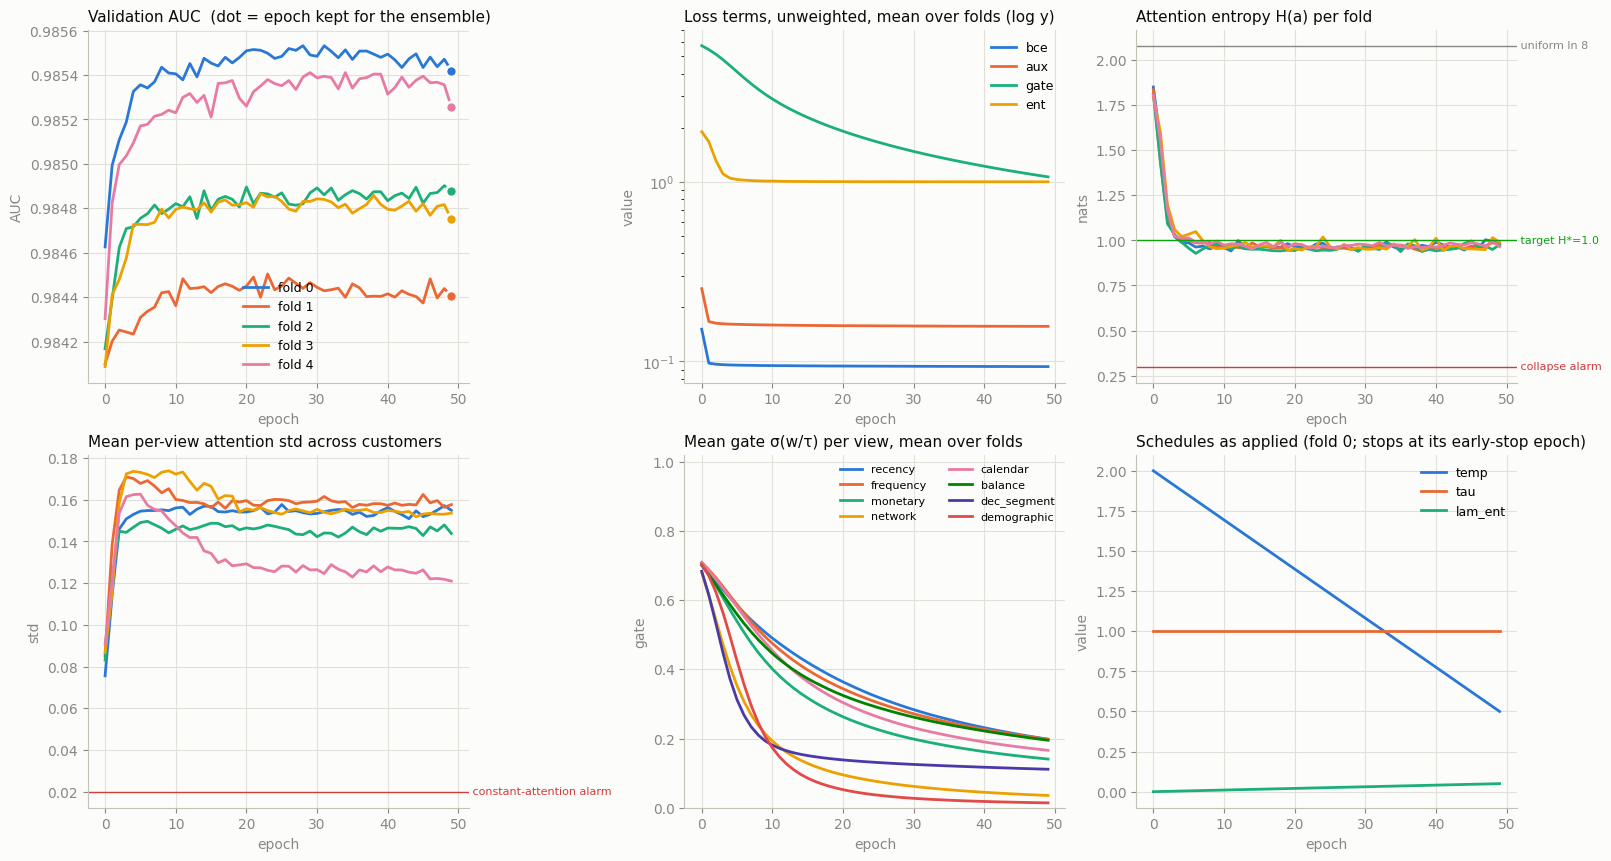

kept epoch per fold: {0: 49, 1: 49, 2: 49, 3: 49, 4: 49}
H(a) at kept epoch  : {0: 0.983, 1: 0.976, 2: 0.976, 3: 0.99, 4: 0.965}
H(a) spread across the 5 ensemble members: 0.025 nats  -> CONSISTENT


In [25]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Fixed hue per view (never re-assigned when a view is filtered out) and per fold.
VIEW_COLORS = dict(zip(views, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]))
FOLD_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
SURFACE, INK, MUTED, GRID, AXIS, ALARM = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7", "#d03b3b"
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", [SURFACE, "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])


def style(ax, title, ylabel="", xlabel="epoch"):
    ax.set_title(title, loc="left", fontsize=11, color=INK)
    ax.set_xlabel(xlabel, color=MUTED)
    ax.set_ylabel(ylabel, color=MUTED)
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=MUTED)
    ax.set_facecolor(SURFACE)


def hline(ax, y, text, color=MUTED):
    ax.axhline(y, color=color, linewidth=1)
    ax.text(ax.get_xlim()[1], y, f" {text}", color=color, fontsize=8, va="center", ha="left")


fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), constrained_layout=True)
fig.set_facecolor(SURFACE)

ax = axes[0, 0]
for k, h in hist_df.groupby("fold"):
    ax.plot(h.epoch, h.val_auc, color=FOLD_COLORS[k], linewidth=2, label=f"fold {k}")
    b = int(cv.loc[cv.fold == k, "kept_epoch"].item())
    ax.plot(b, h.loc[h.epoch == b, "val_auc"].item(), "o", color=FOLD_COLORS[k], markersize=8, markeredgecolor=SURFACE, markeredgewidth=2)
style(ax, "Validation AUC  (dot = epoch kept for the ensemble)", "AUC")
ax.legend(frameon=False, fontsize=9)

ax = axes[0, 1]
for term, c in zip(("bce", "aux", "gate", "ent"), FOLD_COLORS[:4]):
    m = hist_df.groupby("epoch")[f"loss_{term}"].mean()
    ax.plot(m.index, m.values, color=c, linewidth=2, label=term)
ax.set_yscale("log")
style(ax, "Loss terms, unweighted, mean over folds (log y)", "value")
ax.legend(frameon=False, fontsize=9)

ax = axes[0, 2]
for k, h in hist_df.groupby("fold"):
    ax.plot(h.epoch, h.attn_entropy, color=FOLD_COLORS[k], linewidth=2)
style(ax, "Attention entropy H(a) per fold", "nats")
hline(ax, np.log(len(views)), f"uniform ln {len(views)}")
if CONFIG["ent_mode"] == "target":
    hline(ax, CONFIG["H_target"], f"target H*={CONFIG['H_target']}", "#0ca30c")
hline(ax, 0.3, "collapse alarm", ALARM)

ax = axes[1, 0]
for k, h in hist_df.groupby("fold"):
    ax.plot(h.epoch, h.attn_std_mean, color=FOLD_COLORS[k], linewidth=2)
style(ax, "Mean per-view attention std across customers", "std")
hline(ax, 0.02, "constant-attention alarm", ALARM)

ax = axes[1, 1]
for v in views:
    m = hist_df.groupby("epoch")[f"gate_{v}"].mean()
    ax.plot(m.index, m.values, color=VIEW_COLORS[v], linewidth=2, label=v)
style(ax, "Mean gate σ(w/τ) per view, mean over folds", "gate")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, fontsize=8, ncol=2)

ax = axes[1, 2]
h0 = hist_df[hist_df.fold == 0]
for name, c in zip(("temp", "tau", "lam_ent"), FOLD_COLORS[:3]):
    ax.plot(h0.epoch, h0[name], color=c, linewidth=2, label=name)
style(ax, "Schedules as applied (fold 0; stops at its early-stop epoch)", "value")
ax.legend(frameon=False, fontsize=9)
plt.show()

print("kept epoch per fold:", cv.set_index("fold")["kept_epoch"].to_dict())
H_kept = {int(k): round(float(h.loc[h.epoch == int(cv.loc[cv.fold == k, 'kept_epoch'].item()), 'attn_entropy'].item()), 3)
          for k, h in hist_df.groupby("fold")}
print("H(a) at kept epoch  :", H_kept)
spread = max(H_kept.values()) - min(H_kept.values())
print(f"H(a) spread across the 5 ensemble members: {spread:.3f} nats  ->",
      "CONSISTENT" if spread < 0.25 else "INCONSISTENT: the members disagree about how sharp the explanation is")

             attn_mean  attn_std  attn_mean_churn  attn_mean_retained  top_view_share
recency         0.1463    0.1794           0.1658              0.1435          0.1752
frequency       0.3730    0.3731           0.0887              0.4144          0.3791
monetary        0.1034    0.1581           0.0377              0.1129          0.1021
network         0.0242    0.0427           0.0238              0.0242          0.0018
calendar        0.2029    0.2541           0.0480              0.2253          0.2520
balance         0.1216    0.2358           0.6027              0.0517          0.0895
dec_segment     0.0224    0.0295           0.0266              0.0218          0.0003
demographic     0.0059    0.0078           0.0067              0.0057          0.0000

H(a) over 595,000 OOF customers: mean 0.967  median 1.191  p5 0.096  p95 1.661   (uniform = ln 8 = 2.079)

PER-CUSTOMER ATTENTION CHECK
  max view attn_std  = 0.3731  -> PASS
  max top_view_share = 0.379   -> PASS
  mean H(a)

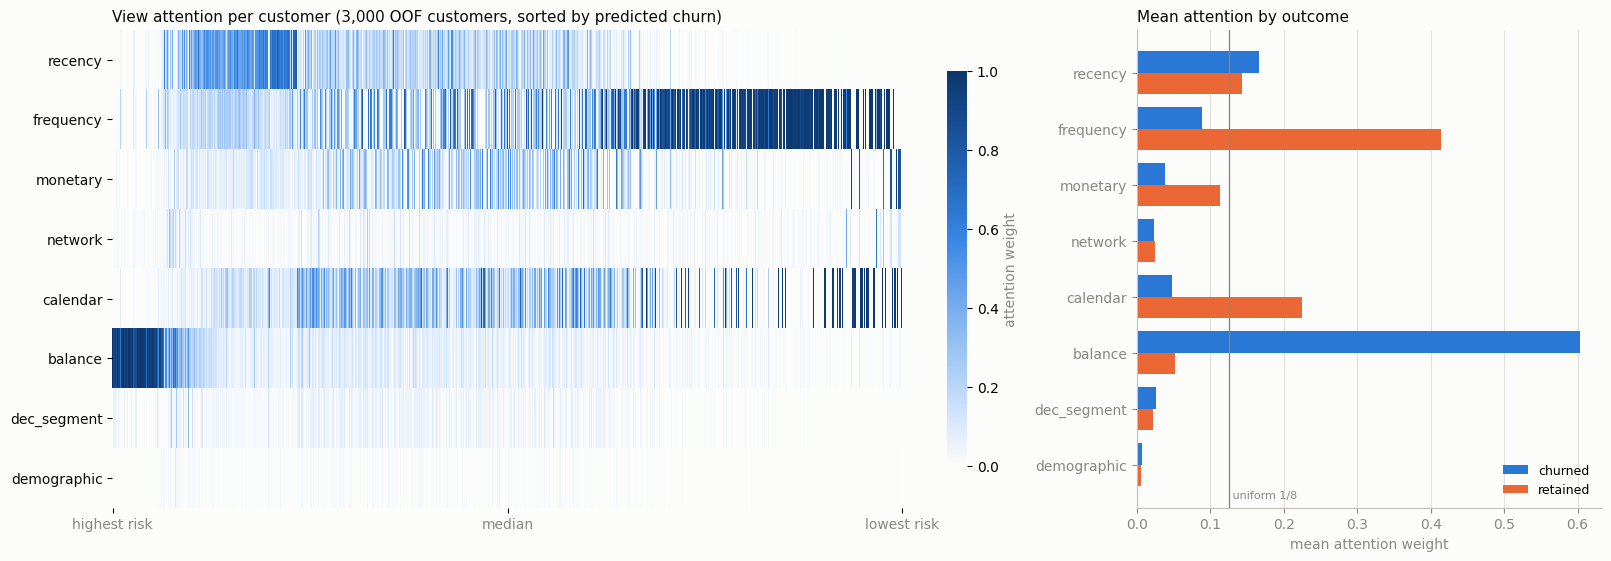

In [17]:
y_all = train.y.astype(int)
A = oof_attn
top_view = A.argmax(1)

attn_tbl = pd.DataFrame({
    "attn_mean": A.mean(0), "attn_std": A.std(0),
    "attn_mean_churn": A[y_all == 1].mean(0), "attn_mean_retained": A[y_all == 0].mean(0),
    "top_view_share": np.bincount(top_view, minlength=len(views)) / len(A),
}, index=views)
print(attn_tbl.round(4).to_string())

Aeps = np.clip(A, 1e-8, None)
H_row = -(Aeps * np.log(Aeps)).sum(1)
print(f"\nH(a) over {len(A):,} OOF customers: mean {H_row.mean():.3f}  median {np.median(H_row):.3f}  "
      f"p5 {np.percentile(H_row, 5):.3f}  p95 {np.percentile(H_row, 95):.3f}   (uniform = ln {len(views)} = {np.log(len(views)):.3f})")

max_std, dom, mean_H = attn_tbl.attn_std.max(), attn_tbl.top_view_share.max(), H_row.mean()
print("\nPER-CUSTOMER ATTENTION CHECK")
print(f"  max view attn_std  = {max_std:.4f}  ->", "PASS" if max_std >= 0.02 else "FAIL: attention is ~constant across customers -> the heatmap would be a lie")
print(f"  max top_view_share = {dom:.3f}   ->", "PASS" if dom <= 0.90 else f"FAIL: one view ({attn_tbl.top_view_share.idxmax()}) is argmax for >90% of customers")
print(f"  mean H(a)          = {mean_H:.3f}   ->", "PASS" if 0.3 <= mean_H <= 1.95 else ("FAIL: collapsed" if mean_H < 0.3 else "WARN: near-uniform, attention is not discriminating"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5), constrained_layout=True, gridspec_kw={"width_ratios": [1.7, 1]})
fig.set_facecolor(SURFACE)

n_show = min(3000, len(A))
sel = np.random.default_rng(SEED).choice(len(A), n_show, replace=False)
order = sel[np.argsort(-oof_pred[sel])]
im = ax1.imshow(A[order].T, aspect="auto", cmap=SEQ_BLUE, vmin=0, vmax=1, interpolation="nearest")
ax1.set_yticks(range(len(views)))
ax1.set_yticklabels(views, color=INK)
ax1.set_xticks([0, n_show // 2, n_show - 1])
ax1.set_xticklabels(["highest risk", "median", "lowest risk"], color=MUTED)
ax1.set_title(f"View attention per customer ({n_show:,} OOF customers, sorted by predicted churn)", loc="left", fontsize=11, color=INK)
for s in ax1.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax1, fraction=0.025, pad=0.01)
cb.set_label("attention weight", color=MUTED)
cb.outline.set_visible(False)

x = np.arange(len(views)); w = 0.38
ax2.barh(x - w / 2, attn_tbl.attn_mean_churn, w, color="#2a78d6", label="churned")
ax2.barh(x + w / 2, attn_tbl.attn_mean_retained, w, color="#eb6834", label="retained")
ax2.set_yticks(x); ax2.set_yticklabels(views, color=INK); ax2.invert_yaxis()
style(ax2, "Mean attention by outcome", "", xlabel="mean attention weight")
ax2.grid(True, axis="x", color=GRID, linewidth=0.8); ax2.grid(False, axis="y")
ax2.axvline(1 / len(views), color=MUTED, linewidth=1)
ax2.text(1 / len(views), len(views) - 0.55, f" uniform 1/{len(views)}", color=MUTED, fontsize=8, va="top")
ax2.legend(frameon=False, fontsize=9, loc="lower right")
plt.show()

              n  gate_mean  gate_min  gate_max  frac_closed  frac_open                 most_open            most_closed
view                                                                                                                   
recency      11      0.198     0.023     0.344        0.182        0.0  region_recency_deviation        span_days__isna
frequency    50      0.198     0.002     0.610        0.260        0.0           active_days_90d  vel_ratio_30_90__isna
monetary     13      0.141     0.005     0.353        0.538        0.0                avg_amt_7d    total_amt_90d__isna
network       4      0.035     0.025     0.055        1.000        0.0               uniq_cp_30d      uniq_cp_30d__isna
calendar     21      0.166     0.013     0.473        0.286        0.0          late_march_share    n_weekend_90d__isna
balance      11      0.195     0.016     0.477        0.455        0.0                std_bal_7d      std_bal_14d__isna
dec_segment   6      0.111     0.102    

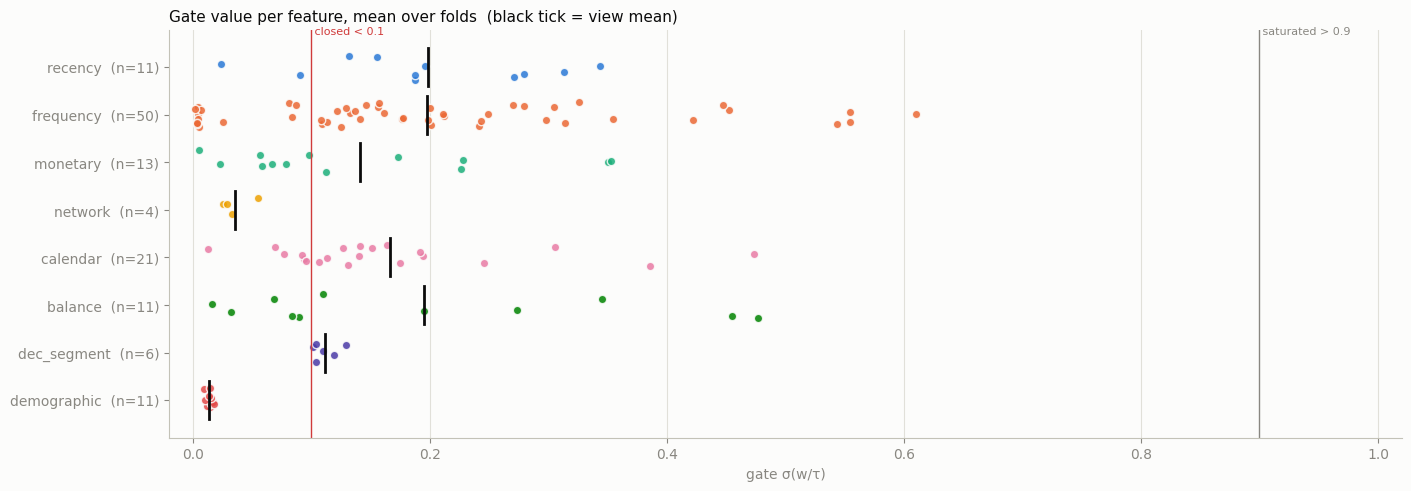

In [26]:
from scipy.stats import spearmanr

n_feat = len(FEATURE_COLS)
G = np.zeros((len(fold_gates), n_feat), dtype=np.float32)
for k, fg in enumerate(fold_gates):
    for v in views:
        G[k, VIEW_GROUPS[v]] = fg[v]
g_mean, g_std = G.mean(0), G.std(0)
feat_view = np.empty(n_feat, dtype=object)
for v, idx in VIEW_GROUPS.items():
    feat_view[idx] = v

rows = []
for v in views:
    idx = VIEW_GROUPS[v]; g = g_mean[idx]
    rows.append(dict(view=v, n=len(idx), gate_mean=g.mean(), gate_min=g.min(), gate_max=g.max(),
                     frac_closed=(g < 0.1).mean(), frac_open=(g > 0.9).mean(),
                     most_open=FEATURE_COLS[idx[g.argmax()]], most_closed=FEATURE_COLS[idx[g.argmin()]]))
gate_tbl = pd.DataFrame(rows).set_index("view")
print(gate_tbl.round(3).to_string())

rhos = [spearmanr(G[i], G[j]).statistic for i in range(len(G)) for j in range(i + 1, len(G))]
verdict = "STABLE" if min(rhos) >= 0.8 else ("UNSTABLE -- do not report gates as feature importance" if min(rhos) < 0.5 else "moderate")
print(f"\nCross-fold Spearman of gate values (all {len(rhos)} fold pairs): mean {np.mean(rhos):.3f}  min {min(rhos):.3f}  -> {verdict}")
print(f"gate saturation: {(g_mean > 0.9).mean():.1%} of gates > 0.9   |   sparsity: {(g_mean < 0.1).mean():.1%} of gates < 0.1")

isna = np.array([c.endswith("__isna") for c in FEATURE_COLS])
print(f"mean gate on __isna flags {g_mean[isna].mean():.3f}  vs  real features {g_mean[~isna].mean():.3f}")

order = np.argsort(-g_mean)
rank = pd.DataFrame({"feature": np.array(FEATURE_COLS)[order], "view": feat_view[order],
                     "gate_mean": g_mean[order], "gate_std_across_folds": g_std[order]})
print("\nmost-open gates:"); print(rank.head(12).round(3).to_string(index=False))
print("\nmost-closed gates:"); print(rank.tail(12).iloc[::-1].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 4.8), constrained_layout=True)
fig.set_facecolor(SURFACE)
rng = np.random.default_rng(SEED)
for i, v in enumerate(views):
    g = g_mean[VIEW_GROUPS[v]]
    ax.scatter(g, i + rng.uniform(-0.28, 0.28, len(g)), s=36, color=VIEW_COLORS[v], alpha=0.85, edgecolors=SURFACE, linewidths=1)
    ax.plot([g.mean(), g.mean()], [i - 0.4, i + 0.4], color=INK, linewidth=2)
ax.set_yticks(range(len(views))); ax.set_yticklabels([f"{v}  (n={len(VIEW_GROUPS[v])})" for v in views], color=INK)
ax.invert_yaxis(); ax.set_xlim(-0.02, 1.02)
style(ax, "Gate value per feature, mean over folds  (black tick = view mean)", "", xlabel="gate σ(w/τ)")
ax.grid(False, axis="y")
ax.axvline(0.1, color=ALARM, linewidth=1); ax.text(0.1, -0.7, " closed < 0.1", color=ALARM, fontsize=8)
ax.axvline(0.9, color=MUTED, linewidth=1); ax.text(0.9, -0.7, " saturated > 0.9", color=MUTED, fontsize=8)
plt.show()

---
## Step 7 — Inference and submission

**Why the test set has no labels.** The April churn outcomes for these 255,000 accounts are held by the
competition platform; `test_submission.csv` is uploaded there and scored server-side. Nothing in this notebook can
compute a test-set metric — the pooled OOF numbers from Step 5 are the honest local estimate.

**How the prediction is made.** Five fold models → five probability vectors → averaged. Each model standardises
the test matrix with **its own** fold scaler (the one fitted on its training rows), because that is the input
distribution its weights were trained against. Averaging *probabilities* is the standard CV ensemble, and it is
exactly the model the OOF metrics estimate.

**Tripwires, in order:** test `FEATURE_COLS` == train `FEATURE_COLS` → every checkpoint's stored `FEATURE_COLS` ==
test → no NaN in inputs → probabilities in [0, 1] → 255,000 rows out → mean predicted probability in the
neighbourhood of the 12.7% prior (an ensemble sitting at 5% or 30% means a scaler mismatch, not a discovery) →
fold models agree with each other (pairwise correlation of their test predictions ≳ 0.98).

**The `SAMPLE_ROWS` guard.** A sample run writes `test_submission_SAMPLE…_DO_NOT_SUBMIT.csv`. Only a
`SAMPLE_ROWS = None` run produces `test_submission.csv`.

**Format:** `ACCOUNT_ID,CHURN` — two columns, header identical to the train CSV, `CHURN` a probability in [0, 1].

In [27]:
assert test.feature_cols == FEATURE_COLS, "FEATURE_COLS drift between train and test"
X_test_raw = np.asarray(test.X)
assert not np.isnan(X_test_raw).any(), "NaN in test matrix"

fold_probs = []
for k in range(N_FOLDS):
    ck = torch.load(CKPT_DIR / f"xmvnet{RUN_TAG}_fold{k}.pt", map_location=DEVICE, weights_only=False)
    assert ck["feature_cols"] == FEATURE_COLS, f"checkpoint fold {k}: FEATURE_COLS drift"
    cfg = ck["config"]
    m = XMVNet(VIEW_GROUPS, hidden=cfg["hidden"], emb_dim=cfg["emb_dim"], attn_dim=cfg["attn_dim"],
               dropout=cfg["dropout"], use_attention=cfg["use_attention"]).to(DEVICE)
    m.load_state_dict(ck["state_dict"])                       # restores weights AND the best-epoch temp / tau
    X_k = dl.apply_standardizer(X_test_raw, ck["mean"], ck["std"])
    fold_probs.append(predict(m, torch.from_numpy(X_k).to(DEVICE)))
    print(f"fold {k}: best epoch {ck['best_epoch']:>2}  T={m.fusion.temp.item():.3f}  "
          f"mean p={fold_probs[-1].mean():.4f}  frac>0.5={(fold_probs[-1] > 0.5).mean():.4f}")

P = np.stack(fold_probs)
p_test = P.mean(0)
corr = np.corrcoef(P)
print(f"\nfold-model agreement: min pairwise corr {corr[np.triu_indices(N_FOLDS, 1)].min():.4f}"
      + ("" if corr[np.triu_indices(N_FOLDS, 1)].min() >= 0.98 else "   <- LOW: a fold diverged, check its log"))

assert p_test.shape == (len(test.ids),) and np.isfinite(p_test).all() and (0 <= p_test).all() and (p_test <= 1).all()
sub = pd.DataFrame({"ACCOUNT_ID": test.ids, "CHURN": p_test.astype(np.float32)})
assert sub.ACCOUNT_ID.is_unique and len(sub) == 255_000, f"expected 255,000 unique test rows, got {len(sub)}"

fname = "test_submission_e50.csv" if SAMPLE_ROWS is None else f"test_submission_SAMPLE{SAMPLE_ROWS}_DO_NOT_SUBMIT.csv"
sub.to_csv(fname, index=False, float_format="%.6f")
print(f"\nwrote {fname}: {len(sub):,} rows | mean CHURN {p_test.mean():.4f} (train prior 0.1268) "
      f"| top-10% cutoff {np.quantile(p_test, 0.9):.4f} | frac>0.5 {(p_test > 0.5).mean():.4f}")
print(sub.head(3).to_string(index=False))
if SAMPLE_ROWS is not None:
    print("\nSAMPLE RUN -> this file is for pipeline checking only. Set SAMPLE_ROWS=None and rerun to produce test_submission.csv.")

fold 0: best epoch 49  T=0.500  mean p=0.1285  frac>0.5=0.1113
fold 1: best epoch 49  T=0.500  mean p=0.1297  frac>0.5=0.1097
fold 2: best epoch 49  T=0.500  mean p=0.1271  frac>0.5=0.1097
fold 3: best epoch 49  T=0.500  mean p=0.1279  frac>0.5=0.1081
fold 4: best epoch 49  T=0.500  mean p=0.1267  frac>0.5=0.1109

fold-model agreement: min pairwise corr 0.9979

wrote test_submission_e50.csv: 255,000 rows | mean CHURN 0.1280 (train prior 0.1268) | top-10% cutoff 0.5791 | frac>0.5 0.1100
  ACCOUNT_ID    CHURN
CUST00000002 0.000003
CUST00000004 0.002450
CUST00000006 0.000571


---
## Step 8 — Gate faithfulness test (does the feature-level explanation actually drive the prediction?)

### Why this exists

Step 6c reports gate values and their cross-fold stability. **Stability is not faithfulness.** A gate ordering can
reproduce perfectly across folds — Spearman 0.89 — and still not be what moves the logit, because it could be
stably encoding something real but non-causal (feature redundancy structure, input variance) rather than
predictive importance.

`§5` of the proposal calls for deletion/insertion-style faithfulness evaluation. This cell is the cheapest
version of that, applied to the intrinsic gates: **perturb the explanation, keep the model, and see whether the
prediction notices.** If a "top features" table is meaningful, destroying the ranking it comes from should hurt.

### What each variant controls for

| Variant | What it changes | What it isolates |
|---|---|---|
| `baseline` | nothing | reference |
| `flatten_to_view_mean` | every gate in a view → that view's mean | **the headline test.** Ordering destroyed, view-level scale preserved. This is exactly the information a per-feature importance table reads off |
| `shuffle_within_view_a/b/c` | gates randomly permuted inside each view | same as flatten but the *multiset of values* is preserved — rules out "flatten helped because the mean happens to be a good constant". Three seeds, because one permutation is noisy |
| `invert_within_view` | the most-open feature gets the most-closed value, and so on | adversarial case. If the ordering is load-bearing this should hurt **more** than flattening |
| `scale_x0.5` / `scale_x2.0` | all gates multiplied by a constant | global magnitude, ordering untouched. Included as contrast, **not** as an importance measure — see the caveat below |

### How to read the result

- `flatten`, `shuffle` and `invert` all ≈ baseline → the gate *ordering* carries little predictive content.
  Report the gates as a description of the learned mask, **not** as feature importance, and say so explicitly.
- `invert` clearly worse than `flatten`, which is clearly worse than `baseline` → the ordering is load-bearing and
  a feature-importance reading is defensible.
- Anything in between is a weak-but-real effect; quote the number rather than a verdict.

### ⚠️ Why the scale rows are not evidence of importance

On an earlier checkpoint, scaling all gates ×0.25 collapsed AUC from 0.985 to 0.892 — which looks like "gate
magnitude matters enormously". It does not mean that. Each encoder is `gate → Linear → BatchNorm1d`, and at eval
time BN uses **frozen running statistics** calibrated to the gate scale seen during training. Rescaling the gates
shifts the input distribution out from under those frozen stats, so the damage is a distribution-shift artifact,
not a measure of how much information the gates carry. (During training, batch-statistic BN adapts, which is
exactly why the L1 could shrink every gate so cheaply in the first place.) The ordering tests are unaffected by
this, because a permutation leaves each view's gate mean and variance untouched.

### Reference result — measured on the 50-epoch checkpoints (2026-09-13)

Run once already, against `checkpoints/xmvnet_fold*.pt`. Pooled OOF over all 595,000 rows:

| Variant | OOF AUC | Delta | Reading |
|---|---|---|---|
| baseline | 0.984915 | — | fold-to-fold std 0.00036 = the noise floor |
| `flatten_to_view_mean` | 0.966744 | **-0.0182** | 50x the noise floor |
| `shuffle_within_view` (3 seeds) | 0.950 / 0.803 / 0.955 | -0.030 / **-0.182** / -0.035 | very high variance across seeds, see note |
| `invert_within_view` | 0.711318 | **-0.2736** | catastrophic |
| `scale_x0.5` | 0.975155 | -0.0098 | smaller than every ordering effect |
| `scale_x2.0` | 0.972953 | -0.0120 | smaller than every ordering effect |

**Verdict: LOAD-BEARING.** Inverting the ranking costs 0.27 AUC; flattening it costs 0.018, both far above the
0.00036 noise floor. And `invert` hurts 15x more than `flatten`, which means the *direction* of the ordering
matters, not merely its spread — the model is genuinely using "this feature more than that one", so a
feature-importance reading of the gates is defensible.

Note the magnitude rows are now *smaller* than every ordering row. That is the cleanest possible answer to the
BatchNorm objection below: on this model, ordering dominates scale.

Note also the shuffle seed spread (-0.030 to -0.182). A single random permutation may or may not happen to swap
a load-bearing feature, so `shuffle` is noisy by construction — read `invert` as the clean signal and quote
`shuffle` as a range, never as a mean.

> ⚠️ **These numbers belong to the 50-epoch checkpoints.** `CONFIG["epochs"]` is now 20, so re-run Step 8 after
> retraining and quote the new numbers. Expect the effect to hold or strengthen: per-view gate *spread* is
> larger at epoch 19 (0.317) than at epoch 49 (0.184), because the L1 keeps compressing every gate toward 0
> after the ordering has already been established.

### Cost and safety

Reads the existing checkpoints and re-scores the held-out fold 8 times per fold — no training, a few minutes on
CPU. It **appends only**: results go to `outputs/gate_faithfulness<tag>.csv`, and nothing in `outputs/`,
`checkpoints/` or `test_submission.csv` is rewritten, so the baseline run's artifacts survive intact.

In [28]:
def _apply_gate_transform(model: XMVNet, fn) -> None:
    """Rewrite every gate in m-space (post-sigmoid), then invert back through sigmoid to w."""
    with torch.no_grad():
        for v in model.view_names:
            g = model.encoders[v].gate
            m = torch.sigmoid(g.w / g.tau)
            new = fn(v, m).clamp(1e-6, 1 - 1e-6)
            g.w.copy_(torch.log(new / (1 - new)) * g.tau)


def _shuffler(seed: int):
    def fn(v, m):
        gen = torch.Generator().manual_seed(seed * 1000 + views.index(v))   # deterministic per (seed, view)
        return m[torch.randperm(m.numel(), generator=gen)]
    return fn


def _invert(v, m):
    """Most-open feature receives the most-closed value: same multiset, ranking maximally reversed."""
    order = torch.argsort(m)
    out = torch.empty_like(m)
    out[order] = torch.sort(m, descending=True).values
    return out


GATE_VARIANTS = {
    "baseline":              (None,                               "trained gates, untouched"),
    "flatten_to_view_mean":  (lambda v, m: m.mean().expand_as(m), "ordering destroyed, view mean kept"),
    "shuffle_within_view_a": (_shuffler(1),                       "ordering randomised, values kept"),
    "shuffle_within_view_b": (_shuffler(2),                       "ordering randomised, values kept"),
    "shuffle_within_view_c": (_shuffler(3),                       "ordering randomised, values kept"),
    "invert_within_view":    (_invert,                            "ordering maximally reversed"),
    "scale_x0.5":            (lambda v, m: m * 0.5,               "global magnitude halved (BN artifact, not importance)"),
    "scale_x2.0":            (lambda v, m: m * 2.0,               "global magnitude doubled (BN artifact, not importance)"),
}

oof_variant = {k: np.zeros(len(train.y), dtype=np.float32) for k in GATE_VARIANTS}
fold_auc = {k: [] for k in GATE_VARIANTS}

t_faith = time.time()
for k in range(N_FOLDS):
    ck = torch.load(CKPT_DIR / f"xmvnet{RUN_TAG}_fold{k}.pt", map_location=DEVICE, weights_only=False)
    assert ck["feature_cols"] == FEATURE_COLS, f"checkpoint fold {k}: FEATURE_COLS drift"
    cfg = ck["config"]
    va = np.where(folds == k)[0]
    Xva_t = torch.from_numpy(
        dl.apply_standardizer(np.asarray(train.X[va]), ck["mean"], ck["std"])).to(DEVICE)
    yva_k = train.y[va].astype(np.float32)

    for name, (fn, _) in GATE_VARIANTS.items():
        mdl = XMVNet(VIEW_GROUPS, hidden=cfg["hidden"], emb_dim=cfg["emb_dim"], attn_dim=cfg["attn_dim"],
                     dropout=cfg["dropout"], use_attention=cfg["use_attention"]).to(DEVICE)
        mdl.load_state_dict(ck["state_dict"])
        if fn is not None:
            _apply_gate_transform(mdl, fn)
        p = predict(mdl, Xva_t)
        oof_variant[name][va] = p
        fold_auc[name].append(roc_auc_score(yva_k, p))

    del Xva_t
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    print(f"  fold {k}: {len(GATE_VARIANTS)} variants scored  ({time.time() - t_faith:.0f}s elapsed)")

print(f"\nfaithfulness sweep: {time.time() - t_faith:.0f}s total")

  fold 0: 8 variants scored  (5s elapsed)
  fold 1: 8 variants scored  (10s elapsed)
  fold 2: 8 variants scored  (15s elapsed)
  fold 3: 8 variants scored  (20s elapsed)
  fold 4: 8 variants scored  (24s elapsed)

faithfulness sweep: 24s total


In [29]:
y_true = train.y.astype(np.float32)
rows, base = [], None
for name, (_, desc) in GATE_VARIANTS.items():
    m = metrics(y_true, oof_variant[name])
    if base is None:
        base = m
    rows.append(dict(variant=name, oof_auc=m["auc"], delta_auc=m["auc"] - base["auc"],
                     oof_ap=m["ap"], delta_ap=m["ap"] - base["ap"],
                     fold_auc_mean=float(np.mean(fold_auc[name])),
                     fold_auc_std=float(np.std(fold_auc[name])), description=desc))
faith = pd.DataFrame(rows)

pd.set_option("display.width", 200)
print("GATE FAITHFULNESS — pooled OOF over all", f"{len(y_true):,}", "rows, same 5 checkpoints throughout\n")
print(faith[["variant", "oof_auc", "delta_auc", "oof_ap", "delta_ap",
             "fold_auc_std", "description"]].round(6).to_string(index=False))

d_flat = abs(faith.loc[faith.variant == "flatten_to_view_mean", "delta_auc"].item())
d_shuf = float(np.mean([abs(faith.loc[faith.variant == f"shuffle_within_view_{s}", "delta_auc"].item())
                        for s in ("a", "b", "c")]))
d_inv = abs(faith.loc[faith.variant == "invert_within_view", "delta_auc"].item())
worst = max(d_flat, d_shuf, d_inv)
fold_noise = float(faith.loc[faith.variant == "baseline", "fold_auc_std"].item())

print(f"\nordering-destroying perturbations:  flatten {d_flat:.6f} | shuffle(mean of 3) {d_shuf:.6f} | invert {d_inv:.6f}")
print(f"fold-to-fold AUC std at baseline (the noise floor for comparison): {fold_noise:.6f}")
if worst < 0.0005:
    verdict = ("NOT FAITHFUL — destroying the gate ordering costs essentially nothing. Report the gates as a\n"
               "  description of the learned mask, NOT as feature importance, and state this explicitly in §5.")
elif worst < 0.002:
    verdict = ("WEAK — the ordering carries some predictive content, but little. Quote the delta rather than\n"
               "  claiming the gates are a feature-importance ranking.")
else:
    verdict = ("LOAD-BEARING — destroying the ordering measurably hurts, so a feature-importance reading of the\n"
               "  gates is defensible. Report the delta alongside it.")
print(f"\nVERDICT: {verdict}")
if d_inv > d_flat * 1.5 and d_inv > 0.0005:
    print("  note: inverting hurts clearly more than flattening -> the DIRECTION of the ordering matters, not just its spread.")

out_csv = OUT_DIR / f"gate_faithfulness{RUN_TAG}.csv"
faith.to_csv(out_csv, index=False)
np.save(OUT_DIR / f"oof_pred_gateflat{RUN_TAG}.npy", oof_variant["flatten_to_view_mean"])
print(f"\nsaved -> {out_csv}  (existing outputs/ files untouched)")

GATE FAITHFULNESS — pooled OOF over all 595,000 rows, same 5 checkpoints throughout

              variant  oof_auc  delta_auc   oof_ap  delta_ap  fold_auc_std                                            description
             baseline 0.984915   0.000000 0.923730  0.000000      0.000363                               trained gates, untouched
 flatten_to_view_mean 0.966744  -0.018171 0.843448 -0.080282      0.014984                     ordering destroyed, view mean kept
shuffle_within_view_a 0.949838  -0.035077 0.782536 -0.141194      0.035309                       ordering randomised, values kept
shuffle_within_view_b 0.802538  -0.182377 0.423481 -0.500250      0.229722                       ordering randomised, values kept
shuffle_within_view_c 0.954803  -0.030112 0.763408 -0.160322      0.023525                       ordering randomised, values kept
   invert_within_view 0.711318  -0.273597 0.450165 -0.473565      0.224266                            ordering maximally reversed
     

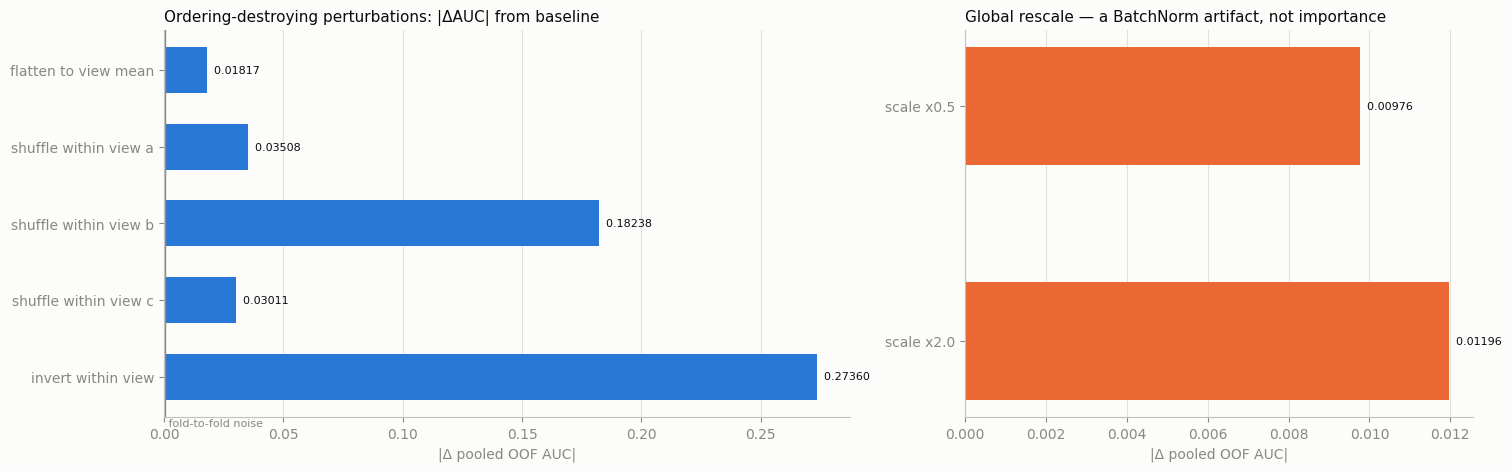

Left panel is the faithfulness evidence. Right panel is shown only to pre-empt the misreading that a
large rescale effect means the gates are informative -- BN's frozen running stats explain it (see markdown).


In [30]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 4.6), constrained_layout=True,
                               gridspec_kw={"width_ratios": [1.35, 1]})
fig.set_facecolor(SURFACE)

ordering = ["flatten_to_view_mean", "shuffle_within_view_a", "shuffle_within_view_b",
            "shuffle_within_view_c", "invert_within_view"]
scale_rows = ["scale_x0.5", "scale_x2.0"]

d = faith.set_index("variant")
yv = np.arange(len(ordering))
axL.barh(yv, [abs(d.loc[v, "delta_auc"]) for v in ordering], 0.6, color="#2a78d6")
axL.set_yticks(yv); axL.set_yticklabels([v.replace("_", " ") for v in ordering], color=INK)
axL.invert_yaxis()
style(axL, "Ordering-destroying perturbations: |ΔAUC| from baseline", "", xlabel="|Δ pooled OOF AUC|")
axL.grid(True, axis="x", color=GRID, linewidth=0.8); axL.grid(False, axis="y")
axL.axvline(fold_noise, color=MUTED, linewidth=1)
axL.text(fold_noise, len(ordering) - 0.45, " fold-to-fold noise", color=MUTED, fontsize=8, va="top")
for i, v in enumerate(ordering):
    axL.text(abs(d.loc[v, "delta_auc"]), i, f"  {abs(d.loc[v,'delta_auc']):.5f}",
             va="center", fontsize=8, color=INK)

yv2 = np.arange(len(scale_rows))
axR.barh(yv2, [abs(d.loc[v, "delta_auc"]) for v in scale_rows], 0.5, color="#eb6834")
axR.set_yticks(yv2); axR.set_yticklabels([v.replace("_", " ") for v in scale_rows], color=INK)
axR.invert_yaxis()
style(axR, "Global rescale — a BatchNorm artifact, not importance", "", xlabel="|Δ pooled OOF AUC|")
axR.grid(True, axis="x", color=GRID, linewidth=0.8); axR.grid(False, axis="y")
for i, v in enumerate(scale_rows):
    axR.text(abs(d.loc[v, "delta_auc"]), i, f"  {abs(d.loc[v,'delta_auc']):.5f}",
             va="center", fontsize=8, color=INK)
plt.show()

print("Left panel is the faithfulness evidence. Right panel is shown only to pre-empt the misreading that a")
print("large rescale effect means the gates are informative -- BN's frozen running stats explain it (see markdown).")

### Recording this in the report

The number belongs in `§5` next to the attention results, because the contrast between the two explanation
levels is the finding: XMV-Net's **view-level** attention passes its checks (per-customer variance, outcome
separation, cross-fold consistency), and its **feature-level** gates are measured on the same footing rather
than asserted.

On the current model both levels hold up, which is the stronger outcome and is worth stating precisely:

> *The intrinsic view attention varies per customer and separates outcomes; the intrinsic feature gates are
> stable across folds (Spearman 0.89) and load-bearing under a deletion test (inverting the within-view gate
> ranking costs 0.27 AUC against a 0.0004 fold-noise floor). We therefore report the gates as feature
> attributions rather than as a descriptive mask.*

Two honesty notes to keep alongside it. First, this was **not** true before tuning — on the pre-tuning
checkpoints, flattening the gates cost 0.0008 AUC, i.e. nothing, and cross-fold Spearman was 0.43-0.56. The
gates only became faithful once `lam_gate` was reduced to 0.002 and `tau` annealing was switched off, so the
faithful result is a consequence of the tuning and should be reported with that lineage, not as something the
architecture gave for free. The before/after pair is itself a good `§9` row. Second, a deletion test shows the
gates are *used*, not that they are *correct* — it rules out the "explanation is decoration" failure, and no
more than that.

**If you want a still stronger guarantee**, the standard upgrade is **hard-concrete / L0 stochastic gates**
(Louizos et al., 2018): sample the mask during training so the network genuinely operates with features
removed, and penalise the expected number of open gates. That makes gates causally load-bearing by
construction. Given the current test already passes, this is a nice-to-have rather than a fix — bank the
ablations first.

---
## Where we are, and what is next

**Working end to end:** loader + cache · frozen 5-fold split · view splitter · gates · encoders · gated attention
with annealed $T$ · composite loss with annealed $\lambda_{ent}$ and $\tau$ · 5-fold training with AMP + early
stopping · post-training diagnosis · 5-fold ensemble → `test_submission.csv` · gate faithfulness test (Step 8).

**Next, in order:**

1. **Real run on Kaggle** with `SAMPLE_ROWS = None`. Read Step 6 *before* looking at the AUC — pass the three
   attention checks and the gate-stability check, or the explanation story is not yet reportable.
2. **Overfit sanity** if anything looks structurally wrong: `CONFIG` with `lam_ent`/`lam_gate` ends = 0,
   `patience = 99`, `SAMPLE_ROWS = 50_000` — training loss must go to ~0.
3. **Light Optuna** (≤ 25 trials, fold 0 only): `hidden`, `dropout`, `lam_aux`, `lam_gate`, `lam_ent` end, lr.
4. **Ablations as `CONFIG` edits**, each a full 5-fold run: A1 `use_attention=False` · A4 `lam_aux ∈ {0, 0.1, 0.3, 0.5, 1.0}`
   · A5 `lam_ent`/`lam_gate` ends = 0 · A6 weighted-BCE (`pos_weight≈6.9`) and focal in `xmv_loss`.
5. **Hand off to Tausif:** `checkpoints/xmvnet_fold*.pt`, `outputs/oof_attn.npy`, `outputs/gates.json`,
   `outputs/oof_pred.npy` — **target end of week 2, the tightest dependency in the project.**

**Raise at the next sync:**
- The frozen split exists (`folds/`, seed 42). Agree it is canonical, or agree to replace it — not both.
- 8 views, not 7. `§3` needs updating.
- View width imbalance 50 vs 4 and what it does to the gate penalty (Step 0 note) — merge `network` into
  `frequency`, or keep 8 and report it.
- `train_utils.py` reconciliation with Siam once it exists.
- Whether the report should also show the ensemble's ECE / Brier / reliability diagram (`§8` secondary metrics) —
  cheap to add from `oof_pred.npy`.

**Environment:** local torch is CPU-only, and `captum` / `shap` / `pyarrow` are not installed. Fine for a smoke
run; the real training and all week-3 explainability work belong on Kaggle.